In [42]:
import pandas as pd
from minisom import MiniSom
import numpy as np

# 读取数据
df = pd.read_excel("插值整合后的数据.xlsx", sheet_name='Sheet1')

In [43]:
df.iloc[:, 1:]

,化合物1,化合物1.1,化合物1.2,化合物1.3,化合物1.4,化合物1.5,化合物1.6,化合物1.7,化合物1.8,化合物1.9,...,化合物20,化合物20.1,化合物20.2,化合物20.3,化合物20.4,化合物20.5,化合物20.6,化合物20.7,化合物20.8,化合物20.9
0,25.003755,15.424768,15.014877,14.915264,12.745902,14.685006,15.039552,14.905498,16.640649,21.056788,...,0.713428,0.713017,0.711801,0.713428,1.067542,1.066539,1.074340,0.499376,0.497479,1.070884
1,16.991687,15.923654,15.770497,15.393188,15.562738,15.141196,15.720825,15.885471,16.063359,16.129358,...,0.710960,0.711560,0.710110,0.710960,1.064950,1.064370,1.072690,0.497660,0.496380,1.068800
2,16.774730,15.948940,15.810440,15.418700,15.660120,15.166550,15.752840,15.930500,16.058750,16.028300,...,0.710818,0.711480,0.710018,0.710818,1.064807,1.064250,1.072600,0.497560,0.496320,1.068686
3,16.134590,16.040050,15.955136,15.511897,15.976300,15.260057,15.866207,16.088382,16.060986,15.770411,...,0.710292,0.711188,0.709678,0.710292,1.064282,1.063809,1.072270,0.497190,0.496102,1.068268
4,15.660120,16.441110,16.592820,15.951410,16.774730,15.719960,16.329510,16.687520,16.392900,16.259330,...,0.707701,0.709788,0.708047,0.707701,1.061745,1.061674,1.070688,0.495360,0.495065,1.066265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1625,50.132910,47.932195,42.687858,44.680172,44.172638,45.931372,46.213659,46.480343,47.717315,43.131716,...,0.173027,0.188149,0.183021,0.173027,0.260189,0.260188,0.246270,0.121109,0.121419,0.277377
1626,49.471650,46.740080,42.830230,45.769400,46.015580,46.506670,45.949880,44.293520,47.026870,40.851450,...,0.171685,0.187305,0.181840,0.171685,0.257923,0.257922,0.245032,0.120146,0.120360,0.276121
1627,46.750137,45.395538,43.288397,46.833510,47.220886,46.862113,45.783159,43.529101,45.488051,41.310644,...,0.170858,0.186765,0.181089,0.170858,0.256521,0.256520,0.244241,0.119556,0.119706,0.275316
1628,45.609578,44.975750,43.480323,47.173097,47.473722,46.968121,45.732837,43.446176,44.784585,42.064983,...,0.170610,0.186600,0.180860,0.170610,0.256100,0.256100,0.244000,0.119380,0.119510,0.275070


In [44]:
# 数据归一化
from sklearn.preprocessing import MinMaxScaler

# 最小-最大归一化
min_max_scaler = MinMaxScaler()
normalized_data = min_max_scaler.fit_transform(df.iloc[:, 1:])

In [45]:
zhegeliebiao = ['化合物一'] * 10 + ['化合物二'] * 10 + ['化合物三'] * 10 + ['化合物四'] * 10 + ['化合物五'] * 10 + ['化合物六'] * 10 + ['化合物七'] * 10 + ['化合物八'] * 10 + ['化合物九'] * 10 + ['化合物十'] * 10 + ['化合物十一'] * 10 + ['化合物十二'] * 10 + ['化合物十三'] * 10 + ['化合物十四'] * 10 + ['化合物十五'] * 10 + ['化合物十六'] * 10 + ['化合物十七'] * 10 + ['化合物十八'] * 10 + ['化合物十九'] * 10 + ['化合物二十'] * 10

In [46]:
normalized_data = pd.DataFrame(normalized_data, columns=zhegeliebiao)

In [47]:
normalized_data

,化合物一,化合物一,化合物一,化合物一,化合物一,化合物一,化合物一,化合物一,化合物一,化合物一,...,化合物二十,化合物二十,化合物二十,化合物二十,化合物二十,化合物二十,化合物二十,化合物二十,化合物二十,化合物二十
0,0.111980,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004096,0.035829,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,0.066541,0.003937,0.005753,0.003928,0.022837,0.003854,0.005518,0.007328,0.000032,0.002433,...,0.995461,0.997235,0.996820,0.995461,0.996812,0.997329,0.998015,0.995492,0.997098,0.997384
2,0.065311,0.004137,0.006057,0.004138,0.023626,0.004068,0.005777,0.007664,0.000000,0.001748,...,0.995200,0.997084,0.996646,0.995200,0.996636,0.997181,0.997906,0.995230,0.996941,0.997241
3,0.061680,0.004856,0.007159,0.004904,0.026189,0.004858,0.006696,0.008845,0.000016,0.000000,...,0.994233,0.996529,0.996007,0.994233,0.995990,0.996638,0.997509,0.994258,0.996365,0.996717
4,0.058989,0.008021,0.012014,0.008517,0.032662,0.008744,0.010448,0.013325,0.002352,0.003314,...,0.989467,0.993872,0.992940,0.989467,0.992869,0.994009,0.995606,0.989450,0.993625,0.994202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1625,0.254497,0.256562,0.210699,0.244660,0.254781,0.263979,0.252504,0.236094,0.222827,0.185442,...,0.006026,0.004038,0.005568,0.006026,0.006816,0.006819,0.003750,0.006132,0.006821,0.003980
1626,0.250747,0.247153,0.211783,0.253613,0.269722,0.268839,0.250367,0.219743,0.217967,0.169988,...,0.003558,0.002437,0.003347,0.003558,0.004029,0.004028,0.002261,0.003603,0.004025,0.002403
1627,0.235312,0.236542,0.215271,0.262359,0.279494,0.271842,0.249017,0.214027,0.207137,0.173100,...,0.002037,0.001411,0.001933,0.002037,0.002303,0.002302,0.001309,0.002053,0.002298,0.001393
1628,0.228844,0.233229,0.216733,0.265151,0.281544,0.272738,0.248609,0.213407,0.202185,0.178212,...,0.001580,0.001099,0.001503,0.001580,0.001786,0.001784,0.001019,0.001590,0.001781,0.001084


In [48]:
data = df.iloc[:, 0]
data = pd.DataFrame(data, columns=["THz"])

In [50]:
data = pd.concat([data, normalized_data], axis=1)

In [51]:
data

,THz,化合物一,化合物一,化合物一,化合物一,化合物一,化合物一,化合物一,化合物一,化合物一,...,化合物二十,化合物二十,化合物二十,化合物二十,化合物二十,化合物二十,化合物二十,化合物二十,化合物二十,化合物二十
0,1.000100,0.111980,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004096,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,1.006720,0.066541,0.003937,0.005753,0.003928,0.022837,0.003854,0.005518,0.007328,0.000032,...,0.995461,0.997235,0.996820,0.995461,0.996812,0.997329,0.998015,0.995492,0.997098,0.997384
2,1.007080,0.065311,0.004137,0.006057,0.004138,0.023626,0.004068,0.005777,0.007664,0.000000,...,0.995200,0.997084,0.996646,0.995200,0.996636,0.997181,0.997906,0.995230,0.996941,0.997241
3,1.008400,0.061680,0.004856,0.007159,0.004904,0.026189,0.004858,0.006696,0.008845,0.000016,...,0.994233,0.996529,0.996007,0.994233,0.995990,0.996638,0.997509,0.994258,0.996365,0.996717
4,1.014709,0.058989,0.008021,0.012014,0.008517,0.032662,0.008744,0.010448,0.013325,0.002352,...,0.989467,0.993872,0.992940,0.989467,0.992869,0.994009,0.995606,0.989450,0.993625,0.994202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1625,5.984000,0.254497,0.256562,0.210699,0.244660,0.254781,0.263979,0.252504,0.236094,0.222827,...,0.006026,0.004038,0.005568,0.006026,0.006816,0.006819,0.003750,0.006132,0.006821,0.003980
1626,5.989075,0.250747,0.247153,0.211783,0.253613,0.269722,0.268839,0.250367,0.219743,0.217967,...,0.003558,0.002437,0.003347,0.003558,0.004029,0.004028,0.002261,0.003603,0.004025,0.002403
1627,5.992300,0.235312,0.236542,0.215271,0.262359,0.279494,0.271842,0.249017,0.214027,0.207137,...,0.002037,0.001411,0.001933,0.002037,0.002303,0.002302,0.001309,0.002053,0.002298,0.001393
1628,5.993280,0.228844,0.233229,0.216733,0.265151,0.281544,0.272738,0.248609,0.213407,0.202185,...,0.001580,0.001099,0.001503,0.001580,0.001786,0.001784,0.001019,0.001590,0.001781,0.001084


In [52]:
data.to_excel('插值整合后的数据进行归一化.xlsx', index=False, engine='openpyxl')

In [55]:
# 设置 SOM 参数
som_size = 20  # SOM 网格大小
num_epochs = 200  # 训练轮数

# SOM实例化
som = MiniSom(som_size, som_size, input_len=9, sigma=1, learning_rate=0.3)

# 准备训练和测试数据
training_data = []
test_data = []

for huahewu in range(20):
    start_train_col = huahewu * 10 + 1  # 训练集的起始列
    train_data = data.iloc[:, start_train_col:start_train_col + 9].values
    training_data.append(train_data)

    test_col = huahewu * 10 + 10  # 测试集列
    test_data.append(data.iloc[:, test_col].values)

# 将训练数据合并
training_data = np.vstack(training_data)

# SOM 初始化
som.random_weights_init(training_data)

# 训练 SOM
som.train(training_data, num_epochs)

# 测试集预测
predictions = []
for huahewu in range(20):
    test_input = data.iloc[:, huahewu * 10 + 10].values.reshape(1, -1)  # 确保形状为 (1, 10)
    # 这里假设你只想取前9个特征进行匹配
    winner = som.winner(test_input[:, :9])  # 找到最佳匹配单元
    predictions.append(winner)

# 打印预测结果
for i, winner in enumerate(predictions):
    print(f"化合物{i + 1}的最佳匹配单元位置: {winner}")

化合物1的最佳匹配单元位置: (15, 4)
化合物2的最佳匹配单元位置: (0, 2)
化合物3的最佳匹配单元位置: (19, 18)
化合物4的最佳匹配单元位置: (8, 8)
化合物5的最佳匹配单元位置: (5, 12)
化合物6的最佳匹配单元位置: (17, 18)
化合物7的最佳匹配单元位置: (19, 18)
化合物8的最佳匹配单元位置: (14, 10)
化合物9的最佳匹配单元位置: (0, 18)
化合物10的最佳匹配单元位置: (14, 10)
化合物11的最佳匹配单元位置: (1, 10)
化合物12的最佳匹配单元位置: (10, 0)
化合物13的最佳匹配单元位置: (8, 1)
化合物14的最佳匹配单元位置: (8, 1)
化合物15的最佳匹配单元位置: (4, 12)
化合物16的最佳匹配单元位置: (8, 1)
化合物17的最佳匹配单元位置: (8, 1)
化合物18的最佳匹配单元位置: (3, 15)
化合物19的最佳匹配单元位置: (7, 1)
化合物20的最佳匹配单元位置: (18, 17)


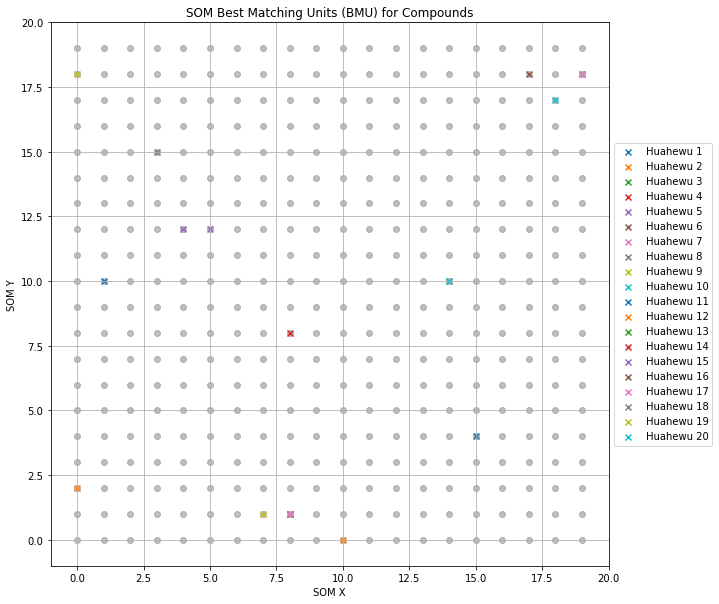

In [57]:
import matplotlib.pyplot as plt

# 设置字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # 或者其他支持的字体
plt.rcParams['axes.unicode_minus'] = False  # 处理负号的显示

# 创建一个 SOM 网格图
plt.figure(figsize=(10, 10))

# 绘制 SOM 网格
for x in range(som_size):
    for y in range(som_size):
        # 获取每个神经元的权重
        weight = som.get_weights()[x, y]
        plt.scatter(x, y, marker='o', color='grey', alpha=0.5)  # 绘制神经元位置

# 绘制每个化合物的 BMU
for huahewu in range(20):
    bmu = predictions[huahewu]  # 获取 BMU 位置
    plt.scatter(bmu[0], bmu[1], marker='x', label=f'Huahewu {huahewu + 1}')

plt.title('SOM Best Matching Units (BMU) for Compounds')
plt.xlabel('SOM X')
plt.ylabel('SOM Y')
plt.xlim(-1, som_size)
plt.ylim(-1, som_size)
plt.grid(True)
# 将图例放到右侧
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [62]:
from sklearn.metrics import accuracy_score
import numpy as np

# 假设test_data和predictions是测试数据和模型预测，且为列表格式
# 如果是列表，可以直接将其转换为 NumPy 数组
y_true = np.array(test_data)
y_pred = np.array(predictions)

# 使用argmax方法获取每个样本的预测类别
if len(y_true.shape) > 1:
    y_true = y_true.argmax(axis=1)
if len(y_pred.shape) > 1:
    y_pred = y_pred.argmax(axis=1)

# 计算准确率
accuracy = accuracy_score(y_true, y_pred)
print(f'SOM模型的准确率：{accuracy * 100:.2f}%')

SOM模型的准确率：25.00%
